# Bundle Tests & New Bundle Layouts

I need to set up methods for making more bundle geometries. Specifically, we need to see a bundle that consists of just two halves and a bundle where the two halves of fiber collections can be separated by a gap.

(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Fiber Bundle'}, xlabel='x (m)', ylabel='y (m)'>)

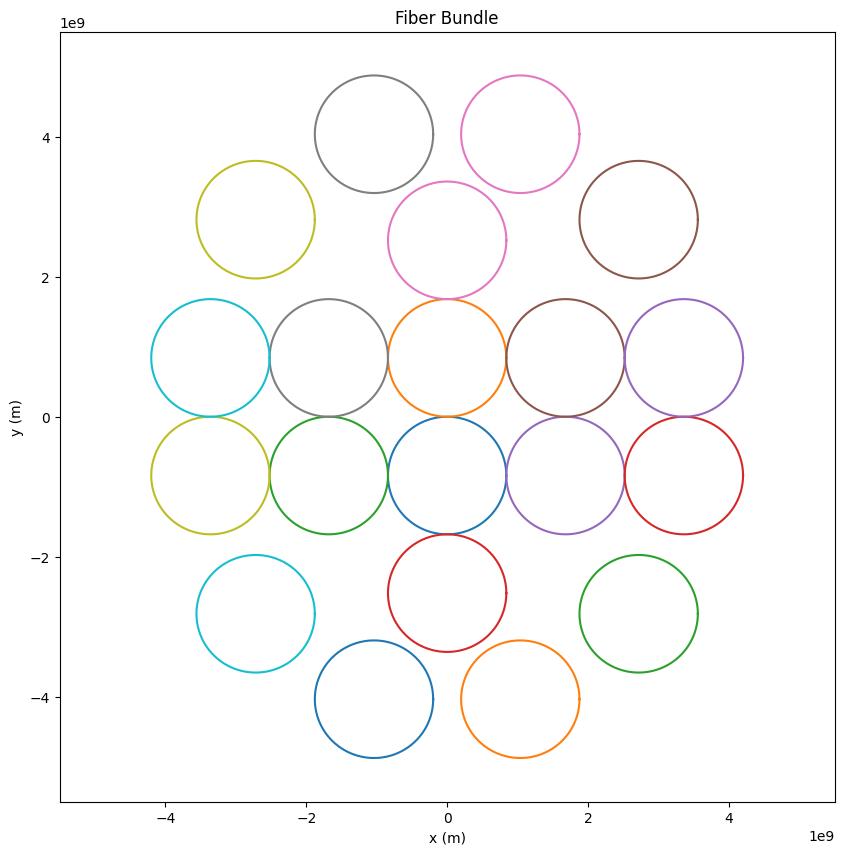

In [1]:
import fiber

b = fiber.FiberBundle(r = 5e-3 * 1e12, core = 200e-6 * 2 * 1e12, cladding = 220e-6 * 2 * 1e12)
b.plot()

Below, I'm making the representation of the two plastic fiber halves. I have made an adjustable gap in the middle, and I've found a method to check if a laser point lies in one of the halves of the bundle.

False
True


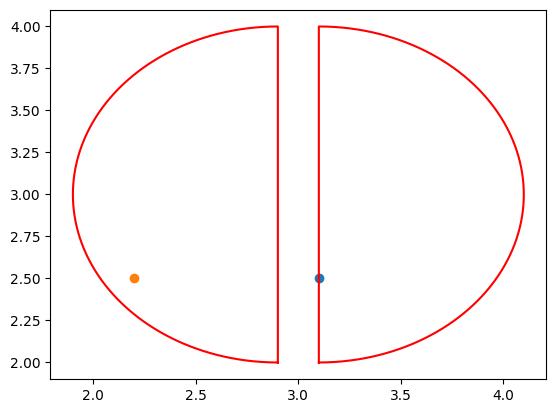

In [46]:
import numpy as np
import matplotlib.pyplot as plt

r = 1
line = 0.1
c = [3, 3]
l = [3.1, 2.5]
x = np.append(np.full(100, c[0] + line), r * np.sin(np.linspace(0, 1, 1000) * np.pi) + line + c[0])
y = np.append(np.linspace(-(r - c[1]), (r + c[1]), 100), r * np.cos(np.linspace(0, 1, 1000) * np.pi) + c[1])
plt.plot(x, y, c = "r")
x = np.append(np.full(100, c[0] - line), r * np.sin(-np.linspace(0, 1, 1000) * np.pi) - line + c[0])
y = np.append(np.linspace(-(r - c[1]), (r + c[1]), 100), r * np.cos(np.linspace(0, 1, 1000) * np.pi) + c[1])
plt.plot(x, y, c = "r")
# plt.plot(r * np.sin(-x * np.pi) - line + c[0], r * np.cos(y * np.pi) + c[1], c = "b")
# plt.vlines([line + c[0], -line + c[0]], -(r - c[1]), (r + c[1]), color = "k")
plt.scatter(l[0], l[1])
neg = 2.2
plt.scatter(neg, l[1])

print((l[0] - c[0] - line) ** 2 + (l[1] - c[1]) ** 2 < (r) ** 2 and l[0] > c[0] + line)
print((neg - c[0] + line) ** 2 + (l[1] - c[1]) ** 2 < (r) ** 2 and neg < c[0] - line)

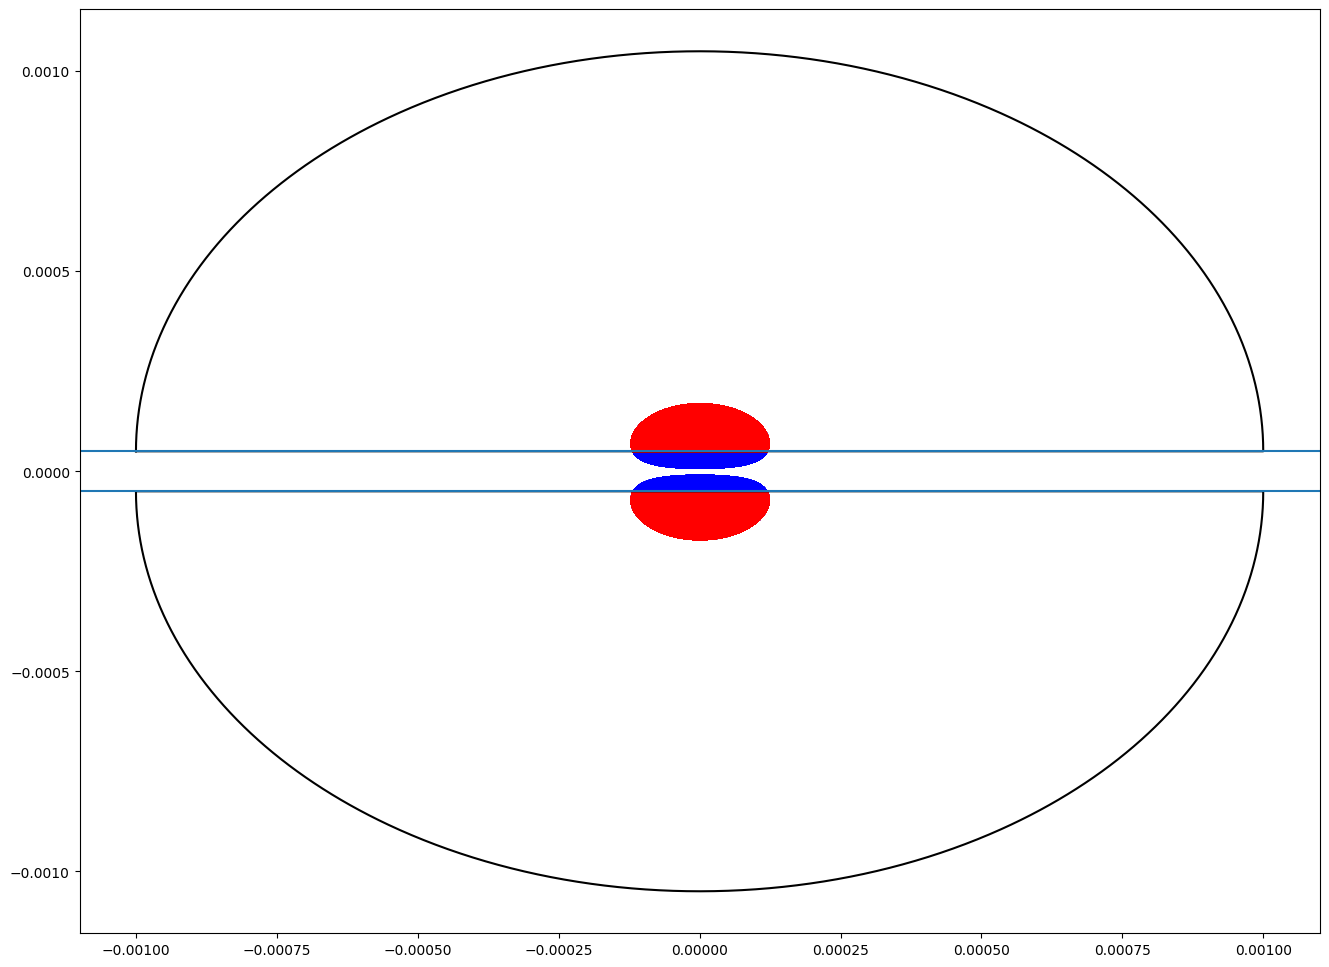

57.508017842542785


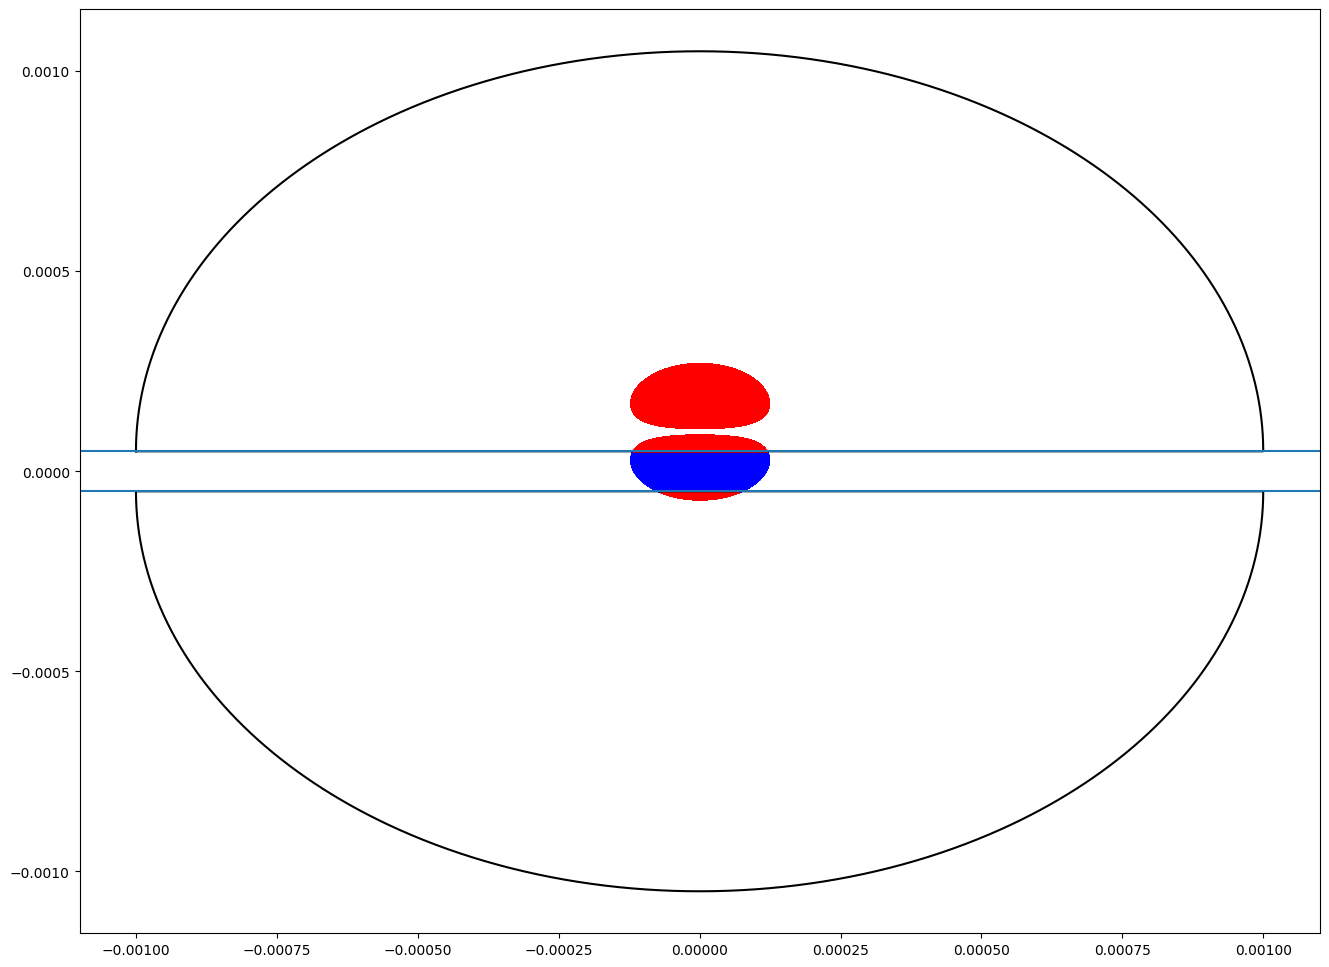

In [10]:
import jax.numpy as jnp
import matplotlib.pyplot as plt
import jax
import laser
from jax import jit
jax.config.update("jax_enable_x64", True)

class plasticbundle:
    def __init__(self, r, gap, center = [0, 0], res = 1000, orientation = "v"):
        self.r = r
        self.gap = gap
        self.res = res
        self.center = center
        self.orientation = orientation
        self.halves = self.draw_bundle(r, gap, res, center, orientation)
        return
    
    @staticmethod
    @jit(static_argnames=["res", "orientation"])
    def draw_bundle(r, gap, res, center, orientation):
        if orientation.upper() == "v".upper():
            f1 = jnp.array([jnp.append(jnp.full(100, center[0] + gap / 2), r * jnp.sin(jnp.linspace(0, 1, res - 100) * jnp.pi) + gap / 2 + center[0]), jnp.append(jnp.linspace(-(r - center[1]), (r + center[1]), 100), r * jnp.cos(jnp.linspace(0, 1, res - 100) * jnp.pi) + center[1])])
            f2 = jnp.array([jnp.append(jnp.full(100, center[0] - gap / 2), r * jnp.sin(-jnp.linspace(0, 1, res - 100) * jnp.pi) - gap / 2 + center[0]), jnp.append(jnp.linspace(-(r - center[1]), (r + center[1]), 100), r * jnp.cos(jnp.linspace(0, 1, res - 100) * jnp.pi) + center[1])])
        else:
            f1 = jnp.array([jnp.append(jnp.linspace(-(r - center[0]), (r + center[0]), 100), r * jnp.cos(jnp.linspace(0, 1, res - 100) * jnp.pi) + center[0]), jnp.append(jnp.full(100, center[1] + gap / 2), r * jnp.sin(jnp.linspace(0, 1, res - 100) * jnp.pi) + gap / 2 + center[1])])
            f2 = jnp.array([jnp.append(jnp.linspace(-(r - center[0]), (r + center[0]), 100), r * jnp.cos(jnp.linspace(0, 1, res - 100) * jnp.pi) + center[0]), jnp.append(jnp.full(100, center[1] - gap / 2), r * jnp.sin(-jnp.linspace(0, 1, res - 100) * jnp.pi) - gap / 2 + center[1])])
        return jnp.array([f1, f2])
    
    def plot(self, ax = None, figsize = (8, 6), im = [], c = "k"):
        import matplotlib.pyplot as plt
        plt.ioff()
        if ax == None:
            fig, ax = plt.subplots(1, 1, figsize = figsize)
        else:
            fig = plt.gcf()
        for h in self.halves:
            ax.plot(h[0], h[1], c = c)
        if len(im) > 0:
            ax.scatter(im.x[~jnp.isnan(im.P)], im.y[~jnp.isnan(im.P)], c = "b", s = 1)
        plt.ion()
        return fig, ax
    
    @jit(static_argnums=(0,2))
    def sum_power(self, l, half = -1):
        P = jnp.where(jnp.isnan(l.P), 0, l.P)
        if self.orientation.upper() == "v".upper():
            half1 = ((l.x - self.center[0] - self.gap / 2) ** 2 + (l.y - self.center[1]) ** 2 < self.r ** 2) & (l.x > self.center[0] + self.gap / 2)
            half2 = ((l.x - self.center[0] + self.gap / 2) ** 2 + (l.y - self.center[1]) ** 2 < self.r ** 2) & (l.x < self.center[0] - self.gap / 2)
        else:
            half1 = ((l.x - self.center[0]) ** 2 + (l.y - self.center[1] - self.gap / 2) ** 2 < self.r ** 2) & (l.y > self.center[1] + self.gap / 2)
            half2 = ((l.x - self.center[0]) ** 2 + (l.y - self.center[1] + self.gap / 2) ** 2 < self.r ** 2) & (l.y < self.center[1] - self.gap / 2)
            
        half1_P = jnp.sum(P * half1)
        half2_P = jnp.sum(P * half2)
        if half == 0:
            return half1_P
        elif half == 1:
            return half2_P
        else:
            return half1_P + half2_P
    @jit(static_argnums=0)
    def diff_power(self, l):
        return self.sum_power(l, 0) - self.sum_power(l, 1)

    def _tree_flatten(self):
        children = (self.halves,)
        aux = {
            "r": self.r, "gap": self.gap, "center": self.center, "res": self.res, "orientation": self.orientation
        }
        return (children, aux)
    @classmethod
    def _tree_unflatten(cls, aux, children):
        obj = cls.__new__(cls)
        obj.r = aux["r"]
        obj.gap = aux["gap"]
        obj.center = aux["center"]
        obj.res = aux["res"]
        obj.orientation = aux["orientation"]
        obj.halves = children
        return obj

jax.clear_caches()
l = jax.block_until_ready(laser.laser(0, 0, 0, waist = 1e-4, power = 102, res = 10000, mode = (0, 1), mode_type = 0, chop = True, chop_threshold = 1e-5))

fig, ax = plt.subplots(1, 1, figsize = (16, 12))
p = plasticbundle(1e-3, 1e-4, orientation = "h")
p.plot(ax, im = l)
ax.axhline(p.gap / 2)
ax.axhline(-p.gap / 2)
ax.scatter(l.x[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] - p.gap / 2) ** 2 < p.r ** 2) & (l.y > p.center[1] + p.gap / 2) & ~jnp.isnan(l.P)], l.y[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] - p.gap / 2) ** 2 < p.r ** 2) & (l.y > p.center[1] + p.gap / 2) & ~jnp.isnan(l.P)], c = "r", s = 1)
ax.scatter(l.x[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] + p.gap / 2) ** 2 < p.r ** 2) & (l.y < p.center[1] - p.gap / 2) & ~jnp.isnan(l.P)], l.y[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] + p.gap / 2) ** 2 < p.r ** 2) & (l.y < p.center[1] - p.gap / 2) & ~jnp.isnan(l.P)], c = "r", s = 1)
plt.show()
p1 = p.diff_power(l)
l = l.dy(1e-4)
p2 = p.diff_power(l)
print(p2 - p1)

fig, ax = plt.subplots(1, 1, figsize = (16, 12))
p.plot(ax, im = l)
ax.axhline(p.gap / 2)
ax.axhline(-p.gap / 2)
ax.scatter(l.x[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] - p.gap / 2) ** 2 < p.r ** 2) & (l.y > p.center[1] + p.gap / 2) & ~jnp.isnan(l.P)], l.y[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] - p.gap / 2) ** 2 < p.r ** 2) & (l.y > p.center[1] + p.gap / 2) & ~jnp.isnan(l.P)], c = "r", s = 1)
ax.scatter(l.x[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] + p.gap / 2) ** 2 < p.r ** 2) & (l.y < p.center[1] - p.gap / 2) & ~jnp.isnan(l.P)], l.y[((l.x - p.center[0]) ** 2 + (l.y - p.center[1] + p.gap / 2) ** 2 < p.r ** 2) & (l.y < p.center[1] - p.gap / 2) & ~jnp.isnan(l.P)], c = "r", s = 1)
plt.show()

(<Figure size 1000x1000 with 1 Axes>, <Axes3D: >)

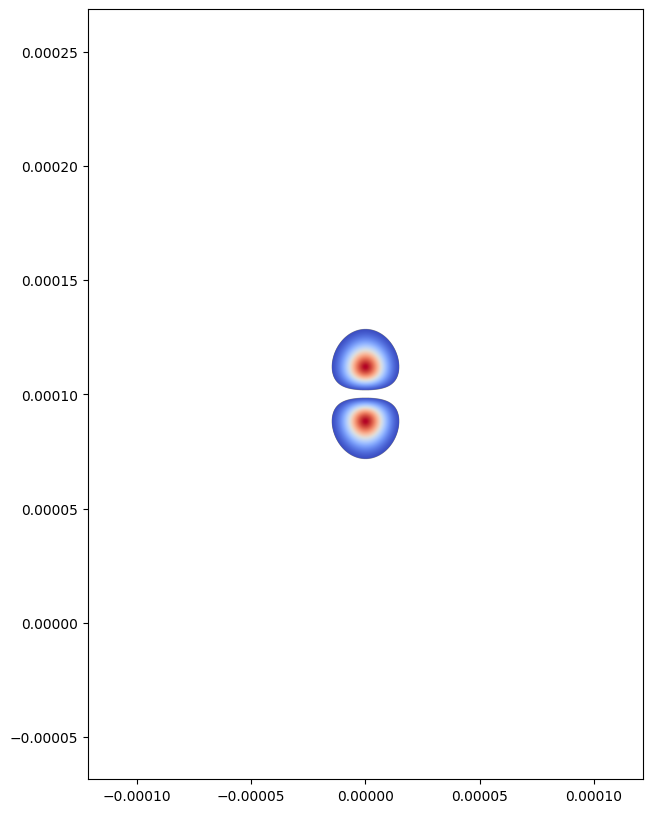

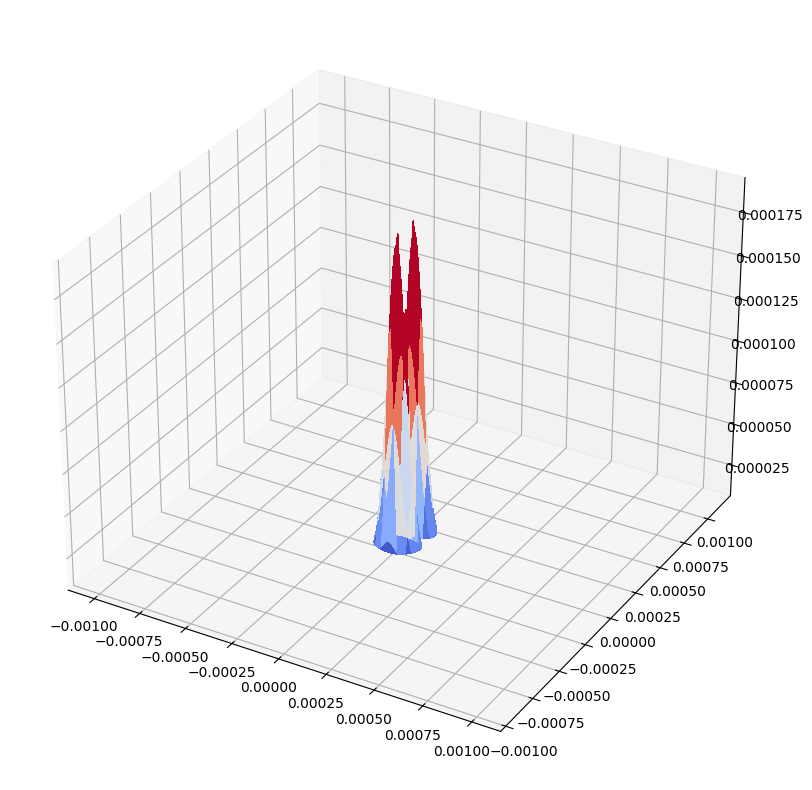

In [12]:
l.imshow()
l.plot_surface()

In [13]:
l = jax.block_until_ready(laser.laser(0, 0, 0, waist = 1e-4, power = 102, res = 10000, mode = (0, 1), mode_type = 0, chop = False, chop_threshold = 1e-5))

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

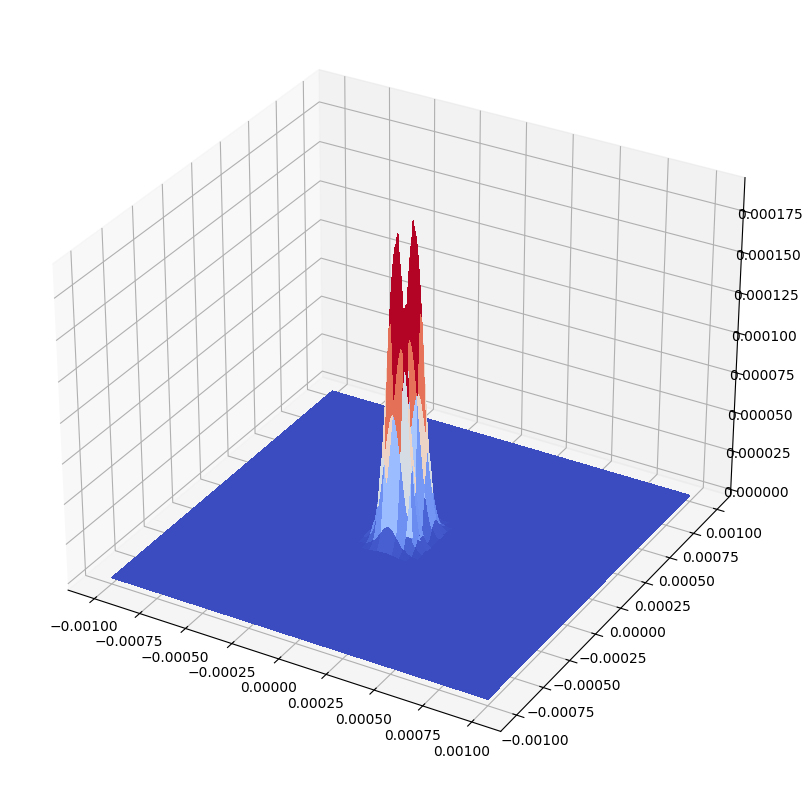

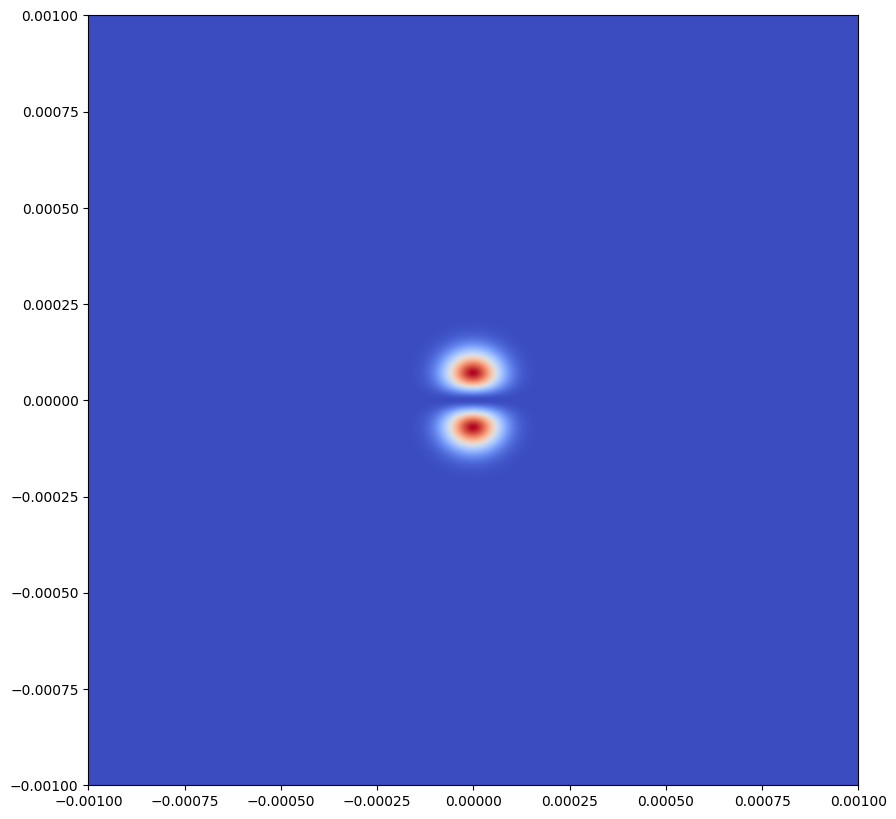

In [15]:
l.plot_surface()
l.imshow()